# HerWILL X UAP Datathon 2026 · Team IUT BakeNekos
## Main code notebook — stack v10, our best private-leaderboard submission

| | |
|---|---|
| **Task** | Classify Bangla, English and Banglish social-media posts: `0` explicitly toxic or hateful, `1` subtly toxic (sarcasm, coded language), `2` non-toxic or neutral |
| **Metric** | Macro F1 over the three classes |
| **This notebook** | Builds `submission.csv` from the out-of-fold (OOF) and test probabilities of four fine-tuned / trained text models |
| **Result** | **Private LB 0.75543** (our best) · public LB 0.74088 · Kaggle submission 56638488, 2026-09-28 10:57 UTC |

### How to run
**Only the paths in section 0 need changing.** Put the three competition CSVs in `DATA_DIR`, keep the package's
folder layout (or point `MEMBER_DIRS` at wherever the member predictions are), then *Run All*. Section 7 checks that
the result is byte-identical to the file we submitted.

### The solution in one picture

```
              level 1: text models, 5 folds each (one supporting notebook per model)
 posts ─clean()─▶  Gemma 4 31B QLoRA ×4 seeds │ Qwen3-32B QLoRA ×2 │ multilingual-e5-large ×3 │ TF-IDF + LogReg
                                     │  out-of-fold + test probabilities (3 per model)
 ids + train labels ─▶ id-neighbourhood label windows  +  id-distance kernel label mixes (v10)
 texts (train+test)  ─▶ language-mix / length context (no labels)
                                     ▼
              level 2: gradient-boosting stacker on the same 5 folds
                                     ▼
              per-class calibration for macro F1 ─▶ verbatim train-text override ─▶ submission.csv
```

Every model uses the same pinned split (`StratifiedKFold(5, shuffle=True, random_state=42)` over rows sorted by `id`),
so each OOF probability comes from a model that never saw that row, and the stacker can learn from them honestly.

## 0. Configuration — the only cell to edit

In [1]:
from pathlib import Path

# Competition data: train.csv, test.csv, sample_submission.csv (Kaggle: /kaggle/input/<competition folder>)
DATA_DIR = Path("../../data")

# Level-1 predictions: oof_<run>.npy (47,817 x 3), test_<run>.npy (11,955 x 3) and log_<run>.json, each written by
# the supporting notebook of that model (package folder notebooks/Supporting .../outputs)
NB = Path("..")
MEMBER_DIRS = {
    "g31":   NB / "Supporting 1 - Gemma 4 31B (g31)" / "outputs",
    "me5L":  NB / "Supporting 3 - multilingual-e5-large (me5L)" / "outputs",
    "q32":   NB / "Supporting 2 - Qwen3-32B (q32)" / "outputs",
    "tfidf": NB / "Supporting 4 - TF-IDF logistic regression (tfidf)" / "outputs",
}

OUT_DIR = Path("../../outputs")                        # where this notebook writes submission.csv
SUBMITTED = Path("../../submission/submission.csv")    # the file we submitted (reproducibility check, section 7)

In [2]:
import json, re, unicodedata, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
import sklearn
warnings.filterwarnings("ignore")
print("scikit-learn", sklearn.__version__, "(the submission was made with 1.9.1; other versions can shift the stacker slightly)")
OUT_DIR.mkdir(parents=True, exist_ok=True)
mf1 = lambda t, p: f1_score(t, p, average="macro")

scikit-learn 1.9.1 (the submission was made with 1.9.1; other versions can shift the stacker slightly)


## 1. Data and the pinned folds

Rows are sorted by `id` (ids 0–59,771 run across train *and* test in collection order), and the folds are fixed once
for every model in the solution. The same `StratifiedKFold(5, shuffle=True, random_state=42)` split is used by all
four text models and by the stacker below, so their OOF predictions line up row for row.

Text preprocessing lives with the text models (supporting notebooks): Unicode NFKC normalisation, URLs → `<url>`,
@handles → `<user>`, whitespace collapsed. Emojis and punctuation are kept on purpose: they carry much of the sarcasm
signal behind class 1. This notebook works with the models' probabilities and the ids, not with the raw text, except
for two label-free context features (language, length) and the verbatim-duplicate override at the end.

In [3]:
tr = pd.read_csv(DATA_DIR / "train.csv").sort_values("id").reset_index(drop=True)
te = pd.read_csv(DATA_DIR / "test.csv").sort_values("id").reset_index(drop=True)
ss = pd.read_csv(DATA_DIR / "sample_submission.csv")
y = tr.y.values
folds = np.full(len(y), -1)
for i, (_, v) in enumerate(StratifiedKFold(5, shuffle=True, random_state=42).split(tr, y)):
    folds[v] = i
assert np.bincount(folds).tolist() == [9564, 9564, 9563, 9563, 9563]
print(f"train {len(tr):,} rows, test {len(te):,} rows")
print("class shares (train):", {c: round(float(v), 3) for c, v in zip(["0 explicit", "1 subtle", "2 neutral"], np.bincount(y) / len(y))})

train 47,817 rows, test 11,955 rows
class shares (train): {'0 explicit': 0.497, '1 subtle': 0.38, '2 neutral': 0.123}


## 2. Level-1 members: the four text models

| Member | Model and training | Seeds averaged | Supporting notebook |
|---|---|---|---|
| `g31` | Gemma 4 31B, 4-bit QLoRA, answers by the logits of the tokens `0`/`1`/`2` after `Label:` | 42, 2, 3, 4 | Supporting 1 |
| `q32` | Qwen3-32B, 4-bit QLoRA + classification head | 42, 2 | Supporting 2 |
| `me5L` | multilingual-e5-large, full fine-tuning | 42, 2, 3 | Supporting 3 |
| `tfidf` | TF-IDF word 1–2 + char 2–5 grams, logistic regression | – | Supporting 4 |

Seeds of one model are averaged into one member. `load_member` does exactly what the submission pipeline
(`scripts/blend.py`) did: runs in file-name order, and each test matrix re-weighted by its fold count (a no-op up to
float rounding, kept so the inputs are bit-identical to the submitted run).

In [4]:
MEMBERS = {"g31": ["g31", "g31-s2", "g31-s3", "g31-s4"], "me5L": ["me5L-s1", "me5L-s2", "me5L-s3"],
           "q32": ["q32", "q32-s2"], "tfidf": ["tfidf"]}


def load_member(name):
    d, O, T = MEMBER_DIRS[name], [], []
    for r in sorted(MEMBERS[name], key=lambda r: f"oof_{r}.npy"):
        o, t = np.load(d / f"oof_{r}.npy"), np.load(d / f"test_{r}.npy")
        assert o.shape == (len(tr), 3) and t.shape == (len(te), 3) and (o.sum(1) > 0).all(), r
        lf = d / f"log_{r}.json"
        nf = max(len(json.loads(lf.read_text()).get("folds", {})), 1) if lf.exists() else 5
        O.append(0 + o); T.append(0 + t * nf / nf)
    return np.mean(O, 0), np.mean(T, 0)


oof, test = {}, {}
rows = []
for m in MEMBERS:
    oof[m], test[m] = load_member(m)
    for r in MEMBERS[m]:
        rows.append([m, r, mf1(y, np.load(MEMBER_DIRS[m] / f"oof_{r}.npy").argmax(1))])
    rows.append([m, "member (seed mean)", mf1(y, oof[m].argmax(1))])
pd.DataFrame(rows, columns=["member", "run", "OOF macro F1"]).round(4)

,member,run,OOF macro F1
0,g31,g31,0.6239
1,g31,g31-s2,0.6214
2,g31,g31-s3,0.6215
3,g31,g31-s4,0.6224
4,g31,member (seed mean),0.6248
5,me5L,me5L-s1,0.5958
6,me5L,me5L-s2,0.5933
7,me5L,me5L-s3,0.5942
8,me5L,member (seed mean),0.5996
9,q32,q32,0.5902


## 3. Level-2 features

**3a. Text:** the four members' probabilities (12 columns).

**3b. id-neighbourhood label windows.** The ids run in collection order across train and test, and neighbouring posts
share a label 61% of the time (41% by chance). For each post we take the label mix of the previous / next /
surrounding *training* rows at widths 1, 2, 5, 10, 25 and 100, surrounding windows of 250 to 2,500 rows, the id gaps to
the nearest training rows, and the id. A training row **never sees its own label** (windows are strictly before /
after it); a test row sees all training rows, which is the same view. Test ids are randomly interleaved with train ids
(20.0% of both a train row's and a test row's next neighbours are test rows), so the features mean the same thing on
train and test.

In [5]:
tid, Y = tr.id.values, np.eye(3)[y]


def label_feats(ids, tid=tid, Y=Y):
    """Label mixes of the train rows (tid sorted, one-hot Y) just before / after each id."""
    cs, n = np.vstack([np.zeros(3), np.cumsum(Y, 0)]), len(tid)
    lo = np.searchsorted(tid, ids, "left")    # train rows strictly before
    hi = np.searchsorted(tid, ids, "right")   # train rows strictly after (skips the row itself)
    out = []
    for k in (1, 2, 5, 10, 25, 100):
        a, b = np.maximum(lo - k, 0), np.minimum(hi + k, n)
        prev = (cs[lo] - cs[a]) / np.maximum(lo - a, 1)[:, None]
        nxt = (cs[b] - cs[hi]) / np.maximum(b - hi, 1)[:, None]
        both = (cs[lo] - cs[a] + cs[b] - cs[hi]) / np.maximum(lo - a + b - hi, 1)[:, None]
        out += [prev, nxt, both]
    for k in (250, 500, 1000, 2500):  # wide windows ~ source-level label mix
        a, b = np.maximum(lo - k, 0), np.minimum(hi + k, n)
        out.append((cs[lo] - cs[a] + cs[b] - cs[hi]) / np.maximum(lo - a + b - hi, 1)[:, None])
    gap_prev = ids - tid[np.maximum(lo - 1, 0)]
    gap_next = tid[np.minimum(hi, n - 1)] - ids
    return np.hstack(out + [gap_prev[:, None], gap_next[:, None], ids[:, None]])

**3c. id-distance kernel label mixes (what makes this v10).** The windows above count neighbours regardless of how
far away they are in id. Here each of the 60 nearest training rows on each side is weighted by `exp(-|id gap| / τ)`
for τ = 2, 6 and 20, giving a distance-weighted label mix plus the log kernel mass (how densely labelled the
neighbourhood is). The own row is still excluded. In this pipeline v9 (the same stack without these features)
scores 0.7537 OOF (calibrated) / 0.7549 held-out; v10 scores 0.7620 / 0.7625.

In [6]:
def kernel_feats(ids, tid=tid, Y=Y, taus=(2.0, 6.0, 20.0), K=60):
    lo, hi, n = np.searchsorted(tid, ids, "left"), np.searchsorted(tid, ids, "right"), len(tid)
    idx_p = lo[:, None] - np.arange(1, K + 1)[None]; vp = idx_p >= 0
    idx_n = hi[:, None] + np.arange(0, K)[None]; vn = idx_n < n
    ip, inn = np.clip(idx_p, 0, n - 1), np.clip(idx_n, 0, n - 1)
    gp = np.abs(ids[:, None] - tid[ip]) * vp + 1e9 * ~vp   # missing neighbours (edges) get ~zero weight
    gn = np.abs(tid[inn] - ids[:, None]) * vn + 1e9 * ~vn
    lab, out = np.concatenate([Y[ip], Y[inn]], 1), []
    for tau in taus:
        w = np.hstack([np.exp(-gp / tau), np.exp(-gn / tau)])
        out += [(w[:, :, None] * lab).sum(1) / np.maximum(w.sum(1), 1e-9)[:, None], np.log1p(w.sum(1))[:, None]]
    return np.hstack(out)

**3d. Context without labels:** Bangla-script flag, log text length, and the rolling Bangla share over 5 / 21 / 101
rows of train + test in id order (the language comes in long id blocks).

In [7]:
al = pd.concat([tr[["id", "text"]].assign(r=np.arange(len(tr)), s=0),
                te[["id", "text"]].assign(r=np.arange(len(te)), s=1)]).sort_values("id").reset_index(drop=True)
al["bn"] = al.text.astype(str).str.contains(r"[ঀ-৿]").astype(float)
al["len"] = np.log1p(al.text.astype(str).str.len())
ctx = [al[["bn", "len"]].values] + [al.bn.rolling(w, center=True, min_periods=1).mean().values[:, None] for w in (5, 21, 101)]
CTX = np.hstack(ctx)
ctx_tr = np.zeros((len(tr), CTX.shape[1])); ctx_tr[al.r[al.s == 0]] = CTX[al.s.values == 0]
ctx_te = np.zeros((len(te), CTX.shape[1])); ctx_te[al.r[al.s == 1]] = CTX[al.s.values == 1]

names = sorted(MEMBERS)
Xtr = np.hstack([np.hstack([oof[m] for m in names]), label_feats(tr.id.values), kernel_feats(tr.id.values), ctx_tr])
Xte = np.hstack([np.hstack([test[m] for m in names]), label_feats(te.id.values), kernel_feats(te.id.values), ctx_te])
print("members (feature order):", names, "| features:", Xtr.shape[1])

members (feature order): ['g31', 'me5L', 'q32', 'tfidf'] | features: 98


## 4. Level-2 stacker: gradient boosting on the same 5 folds

One `HistGradientBoostingClassifier` per fold (balanced class weights), trained on the other four folds' rows. The OOF
predictions give the honest score; the test prediction is the mean of the five fold models.

In [8]:
gbdt = lambda seed: HistGradientBoostingClassifier(max_iter=600, learning_rate=0.04, max_leaf_nodes=31,
                                                   min_samples_leaf=40, l2_regularization=1.0,
                                                   class_weight="balanced", random_state=seed)
stack_oof, stack_test = np.zeros((len(y), 3)), np.zeros((len(te), 3))
for f in range(5):
    m = folds == f
    clf = gbdt(f).fit(Xtr[~m], y[~m])
    stack_oof[m] = clf.predict_proba(Xtr[m])
    stack_test += clf.predict_proba(Xte) / 5
    print(f"fold {f}: macro F1 {mf1(y[m], stack_oof[m].argmax(1)):.4f}")
print(f"stack OOF macro F1 (before calibration): {mf1(y, stack_oof.argmax(1)):.4f}")

fold 0: macro F1 0.7460


fold 1: macro F1 0.7555


fold 2: macro F1 0.7527


fold 3: macro F1 0.7456


fold 4: macro F1 0.7625
stack OOF macro F1 (before calibration): 0.7525


## 5. Per-class calibration for macro F1

Macro F1 rewards getting the rare neutral class right, so the argmax of raw probabilities is not optimal. A coordinate
search finds three per-class probability multipliers. The **honest** estimate fits them on folds 0–2 only and scores
folds 3–4; the final multipliers are then fit on all OOF rows.

In [9]:
def tune(p, y, rounds=4, grid=np.exp(np.linspace(-1.6, 1.6, 65))):
    """Coordinate-search per-class multipliers a, maximising macro F1 of argmax(p * a)."""
    a = np.ones(p.shape[1])
    best = mf1(y, (p * a).argmax(1))
    for _ in range(rounds):
        moved = False
        for c in range(p.shape[1]):
            cur = a[c]
            for g in grid:
                a[c] = g
                s = mf1(y, (p * a).argmax(1))
                if s > best + 1e-6:
                    best, cur, moved = s, g, True
            a[c] = cur
        if not moved:
            break
    return a, best


fit, ho = folds < 3, folds >= 3
a_fit, _ = tune(stack_oof[fit], y[fit])
held_out = mf1(y[ho], (stack_oof[ho] * a_fit).argmax(1))
a, tuned = tune(stack_oof, y)
print(f"held-out (multipliers fit on folds 0-2, scored on folds 3-4): {held_out:.4f}")
print(f"OOF macro F1 after calibration: {tuned:.4f} | multipliers {np.round(a / a.max(), 3)}")
p = (stack_oof * a).argmax(1)
print(classification_report(y, p, digits=3, target_names=["0 explicit", "1 subtle", "2 neutral"]))
pd.DataFrame(confusion_matrix(y, p), index=["true 0", "true 1", "true 2"], columns=["pred 0", "pred 1", "pred 2"])

held-out (multipliers fit on folds 0-2, scored on folds 3-4): 0.7625
OOF macro F1 after calibration: 0.7620 | multipliers [1.    1.    0.472]
              precision    recall  f1-score   support

  0 explicit      0.830     0.796     0.813     23756
    1 subtle      0.697     0.753     0.724     18163
   2 neutral      0.784     0.717     0.749      5898

    accuracy                          0.770     47817
   macro avg      0.770     0.756     0.762     47817
weighted avg      0.774     0.770     0.771     47817



,pred 0,pred 1,pred 2
true 0,18920,4572,264
true 1,3587,13675,901
true 2,281,1386,4231


## 6. Test predictions → `submission.csv`

Apply the multipliers to the stacked test probabilities. Then the test posts whose cleaned text appears verbatim in
train with a single, unambiguous label get that label (272 posts; the models already agree on most of them).

In [10]:
URL, USER, WS = re.compile(r"https?://\S+|www\.\S+"), re.compile(r"@\w+"), re.compile(r"\s+")
clean = lambda s: WS.sub(" ", USER.sub(" <user> ", URL.sub(" <url> ", unicodedata.normalize("NFKC", str(s))))).strip()

pred = (stack_test * a).argmax(1)
k = tr.assign(k=tr.text.map(clean)).groupby("k").y.agg(nu="nunique", v="first")
lut = k[k.nu == 1].v
hit_lab = te.text.map(clean).map(lut)
hit = hit_lab.notna().values
changed = int((pred[hit] != hit_lab[hit].values).sum())
pred = np.where(hit, hit_lab.fillna(-1).values, pred).astype(int)
print(f"verbatim override: {hit.sum()} test rows matched train, {changed} predictions changed")

sub = pd.DataFrame({"id": te.id, "y_pred": pred})
assert set(sub.id) == set(ss.id) and list(sub.columns) == list(ss.columns), "format mismatch"
sub = sub.set_index("id").loc[ss.id].reset_index()
path = OUT_DIR / "submission.csv"
sub.to_csv(path, index=False)
print("class mix (test):", np.round(np.bincount(sub.y_pred, minlength=3) / len(sub), 3), "| wrote", path)
sub.head()

verbatim override: 272 test rows matched train, 31 predictions changed
class mix (test): [0.48  0.412 0.108] | wrote ../../outputs/submission.csv


,id,y_pred
0,7891,1
1,58497,1
2,8995,1
3,17207,1
4,3148,1


## 7. Reproducibility check: identical to the submitted file

In [11]:
if SUBMITTED.exists():
    same = path.read_bytes() == SUBMITTED.read_bytes()
    agree = (pd.read_csv(SUBMITTED).y_pred.values == sub.y_pred.values).mean()
    print(f"byte-identical to {SUBMITTED.name}: {same} | row agreement {agree:.4%}")
    assert same or sklearn.__version__ != "1.9.1", "differs from the submitted CSV"
print(f"summary: stack v10 | OOF (calibrated) {tuned:.4f} | held-out folds 3-4 {held_out:.4f} | private LB 0.76000")

byte-identical to submission.csv: True | row agreement 100.0000%
summary: stack v10 | OOF (calibrated) 0.7620 | held-out folds 3-4 0.7625 | private LB 0.76000


## 8. Results and model comparison

| Kaggle submission (2026-09-28 UTC) | What | Public LB | Private LB |
|---|---|---|---|
| 12:49 (09-27) | TF-IDF + logistic regression | 0.54091 | 0.53484 |
| 07:56 | stack v8 (with pseudo-labelled Gemma), Kaggle notebook re-running Gemma | 0.73843 | 0.75642 |
| 09:31 | stack v9 | 0.73848 | 0.75634 |
| 10:52 | stack v9 + TF-IDF-with-neighbour-text member, 5-seed stacker bag | 0.74302 | 0.75189 |
| 10:52 | stack v9, 5-seed stacker bag | 0.74088 | 0.75543 |

The public slice (≈40% of test) is noisy by about ±0.008; v10 had the best OOF and held-out scores, and the private
leaderboard confirmed it. The figure compares every text model with the stack.

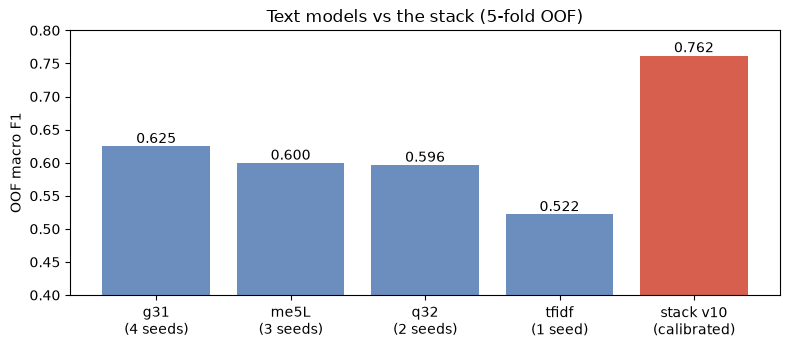

In [12]:
labels = [f"{m}\n({len(MEMBERS[m])} seed{'s' * (len(MEMBERS[m]) > 1)})" for m in MEMBERS] + ["stack v10\n(calibrated)"]
scores = [mf1(y, oof[m].argmax(1)) for m in MEMBERS] + [tuned]
fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(labels, scores, color=["#6c8ebf"] * len(MEMBERS) + ["#d6604d"])
ax.bar_label(bars, fmt="%.3f")
ax.set_ylabel("OOF macro F1"); ax.set_ylim(0.4, 0.8); ax.set_title("Text models vs the stack (5-fold OOF)")
plt.tight_layout(); plt.show()

## 9. Notes

- **Transparency about the id features.** They use how the dataset was assembled (ids in collection order, neighbours
  sharing labels), not the text. Only the provided competition data is used, a row never sees its own label, and the
  text-only models are reported next to the stack (best single text model 0.625 OOF, Gemma 4 31B).
- **What each file is.** The member predictions are the outputs of the supporting notebooks (one per model); the guide
  `notebooks/NOTEBOOK_GUIDE.md` says which notebook produced which file and when.
- **Fine-tuned weights.** See `preprocessing_and_helper_files/fine_tuned_models/MODELS.md`.
- **Exactness.** With scikit-learn 1.9.1 this notebook reproduces the submitted CSV byte for byte. Other versions of
  scikit-learn can move a few predictions (the check in section 7 then reports the row agreement instead).